In [4]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 1 — LOAD FULL ONLINE RETAIL II DATASET
# ============================================================

import io
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("=" * 80)
print("PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Download dataset
# ------------------------------------------------------------

url = (
    "https://archive.ics.uci.edu/"
    "static/public/502/online+retail+ii.zip"
)

print("\nDownloading Online Retail II...")

response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()

print(
    f"Downloaded: "
    f"{len(response.content) / (1024**2):.2f} MB"
)

# ------------------------------------------------------------
# 2. Open ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(
    io.BytesIO(response.content)
) as z:

    print("\nFiles inside ZIP:")

    for file in z.namelist():
        print(" -", file)

    excel_files = [
        file
        for file in z.namelist()
        if file.lower().endswith(
            (".xlsx", ".xls")
        )
    ]

    if not excel_files:
        raise FileNotFoundError(
            "Excel dataset not found."
        )

    excel_file = excel_files[0]

    print(
        "\nSelected file:",
        excel_file
    )

    # --------------------------------------------------------
    # 3. Detect all Excel sheets
    # --------------------------------------------------------

    with z.open(
        excel_file
    ) as file:

        excel_data = file.read()

excel_buffer = io.BytesIO(
    excel_data
)

xls = pd.ExcelFile(
    excel_buffer
)

print(
    "\nAvailable sheets:"
)

print(
    xls.sheet_names
)

# ------------------------------------------------------------
# 4. Read ALL sheets
# ------------------------------------------------------------

dataframes = []

for sheet_name in xls.sheet_names:

    print(
        f"\nLoading sheet: {sheet_name}"
    )

    sheet_df = pd.read_excel(
        xls,
        sheet_name=sheet_name
    )

    print(
        f"Rows loaded: {len(sheet_df):,}"
    )

    dataframes.append(
        sheet_df
    )

# ------------------------------------------------------------
# 5. Combine all sheets
# ------------------------------------------------------------

df = pd.concat(
    dataframes,
    ignore_index=True
)

# ------------------------------------------------------------
# 6. Standardize column names
# ------------------------------------------------------------

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

print(
    "\n" + "=" * 80
)

print(
    "FULL DATASET INFORMATION"
)

print(
    "=" * 80
)

print(
    f"\nShape: {df.shape}"
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)

# ------------------------------------------------------------
# 7. Data types
# ------------------------------------------------------------

print(
    "\nData types:"
)

print(
    df.dtypes
)

# ------------------------------------------------------------
# 8. First rows
# ------------------------------------------------------------

print(
    "\nFirst 5 rows:"
)

display(
    df.head()
)

# ------------------------------------------------------------
# 9. Missing values
# ------------------------------------------------------------

print(
    "\nMissing values:"
)

missing_report = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    missing_report
)

# ------------------------------------------------------------
# 10. Duplicate rows
# ------------------------------------------------------------

duplicate_count = (
    df.duplicated()
    .sum()
)

print(
    f"\nDuplicate rows: "
    f"{duplicate_count:,}"
)

# ------------------------------------------------------------
# 11. Basic date check
# ------------------------------------------------------------

if "InvoiceDate" in df.columns:

    df["InvoiceDate"] = pd.to_datetime(
        df["InvoiceDate"],
        errors="coerce"
    )

    print(
        "\nDate range:"
    )

    print(
        df["InvoiceDate"].min()
    )

    print(
        "to"
    )

    print(
        df["InvoiceDate"].max()
    )

# ------------------------------------------------------------
# 12. Customer coverage
# ------------------------------------------------------------

if "Customer ID" in df.columns:

    customer_count = (
        df["Customer ID"]
        .nunique(
            dropna=True
        )
    )

    print(
        f"\nUnique customers "
        f"with available Customer ID: "
        f"{customer_count:,}"
    )

# ------------------------------------------------------------
# 13. Final diagnostic
# ------------------------------------------------------------

print(
    "\n" + "=" * 80
)

print(
    "DATASET COVERAGE CHECK"
)

print(
    "=" * 80
)

print(
    f"Total rows       : "
    f"{len(df):,}"
)

print(
    f"Total columns    : "
    f"{len(df.columns)}"
)

print(
    f"Duplicate rows   : "
    f"{duplicate_count:,}"
)

print(
    f"Missing Customer IDs: "
    f"{df['Customer ID'].isna().sum():,}"
)

print(
    "\nFull Online Retail II dataset loaded."
)

PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION

Downloaded: 43.51 MB

Files inside ZIP:
 - online_retail_II.xlsx

Selected file: online_retail_II.xlsx

Available sheets:
['Year 2009-2010', 'Year 2010-2011']

Loading sheet: Year 2009-2010
Rows loaded: 525,461

Loading sheet: Year 2010-2011
Rows loaded: 541,910

FULL DATASET INFORMATION

Shape: (1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Missing values:


,0
Customer ID,243007
Description,4382
StockCode,0
Invoice,0
Quantity,0
InvoiceDate,0
Price,0
Country,0



Duplicate rows: 34,335

Date range:
2009-12-01 07:45:00
to
2011-12-09 12:50:00

Unique customers with available Customer ID: 5,942

DATASET COVERAGE CHECK
Total rows       : 1,067,371
Total columns    : 8
Duplicate rows   : 34,335
Missing Customer IDs: 243,007

Full Online Retail II dataset loaded.


In [5]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 2 — FULL DATA CLEANING & TRANSACTION PREPARATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Copy full dataset
# ------------------------------------------------------------

clean_df = df.copy()

print("=" * 80)
print("FULL DATA CLEANING & TRANSACTION PREPARATION")
print("=" * 80)

print(
    f"\nOriginal rows: {len(clean_df):,}"
)

# ------------------------------------------------------------
# 2. Standardize column names
# ------------------------------------------------------------

clean_df = clean_df.rename(
    columns={
        "Invoice": "InvoiceNo",
        "StockCode": "StockCode",
        "Description": "Description",
        "Quantity": "Quantity",
        "InvoiceDate": "InvoiceDate",
        "Price": "UnitPrice",
        "Customer ID": "CustomerID",
        "Country": "Country"
    }
)

# ------------------------------------------------------------
# 3. Convert data types
# ------------------------------------------------------------

clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"],
    errors="coerce"
)

clean_df["Quantity"] = pd.to_numeric(
    clean_df["Quantity"],
    errors="coerce"
)

clean_df["UnitPrice"] = pd.to_numeric(
    clean_df["UnitPrice"],
    errors="coerce"
)

clean_df["CustomerID"] = pd.to_numeric(
    clean_df["CustomerID"],
    errors="coerce"
)

# ------------------------------------------------------------
# 4. Missing CustomerID
# ------------------------------------------------------------

missing_customer_id = (
    clean_df["CustomerID"]
    .isna()
    .sum()
)

print(
    f"\nMissing CustomerID: "
    f"{missing_customer_id:,}"
)

# Keep only customer-attributed transactions
clean_df = clean_df[
    clean_df["CustomerID"].notna()
].copy()

print(
    f"Rows after CustomerID filter: "
    f"{len(clean_df):,}"
)

# ------------------------------------------------------------
# 5. Remove exact duplicate rows
# ------------------------------------------------------------

duplicate_before = (
    clean_df.duplicated()
    .sum()
)

clean_df = (
    clean_df
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicate_after = (
    clean_df.duplicated()
    .sum()
)

print(
    f"\nDuplicates removed: "
    f"{duplicate_before:,}"
)

print(
    f"Remaining duplicates: "
    f"{duplicate_after:,}"
)

# ------------------------------------------------------------
# 6. Remove invalid dates
# ------------------------------------------------------------

invalid_dates = (
    clean_df["InvoiceDate"]
    .isna()
    .sum()
)

clean_df = clean_df[
    clean_df["InvoiceDate"].notna()
].copy()

print(
    f"Invalid dates removed: "
    f"{invalid_dates:,}"
)

# ------------------------------------------------------------
# 7. Identify cancellations
# ------------------------------------------------------------

clean_df["InvoiceNo"] = (
    clean_df["InvoiceNo"]
    .astype(str)
    .str.strip()
)

clean_df["IsCancellation"] = (
    clean_df["InvoiceNo"]
    .str.upper()
    .str.startswith("C")
)

cancellation_count = (
    clean_df["IsCancellation"]
    .sum()
)

print(
    f"Cancellations identified: "
    f"{cancellation_count:,}"
)

# ------------------------------------------------------------
# 8. Identify invalid quantity / price
# ------------------------------------------------------------

invalid_quantity = (
    clean_df["Quantity"] <= 0
).sum()

invalid_price = (
    clean_df["UnitPrice"] <= 0
).sum()

print(
    f"Non-positive quantity rows: "
    f"{invalid_quantity:,}"
)

print(
    f"Non-positive price rows: "
    f"{invalid_price:,}"
)

# ------------------------------------------------------------
# 9. Keep positive revenue transactions
# ------------------------------------------------------------

clean_df = clean_df[
    (clean_df["Quantity"] > 0)
    &
    (clean_df["UnitPrice"] > 0)
].copy()

# ------------------------------------------------------------
# 10. Revenue calculation
# ------------------------------------------------------------

clean_df["Revenue"] = (
    clean_df["Quantity"]
    *
    clean_df["UnitPrice"]
)

# ------------------------------------------------------------
# 11. Exclude cancellation invoices from CLV
# ------------------------------------------------------------

model_df = clean_df[
    ~clean_df["IsCancellation"]
].copy()

# ------------------------------------------------------------
# 12. Remove helper flag
# ------------------------------------------------------------

model_df = model_df.drop(
    columns=["IsCancellation"]
)

# ------------------------------------------------------------
# 13. Customer-level coverage
# ------------------------------------------------------------

unique_customers = (
    model_df["CustomerID"]
    .nunique()
)

unique_invoices = (
    model_df["InvoiceNo"]
    .nunique()
)

# ------------------------------------------------------------
# 14. Date coverage
# ------------------------------------------------------------

min_date = (
    model_df["InvoiceDate"]
    .min()
)

max_date = (
    model_df["InvoiceDate"]
    .max()
)

# ------------------------------------------------------------
# 15. Revenue coverage
# ------------------------------------------------------------

total_revenue = (
    model_df["Revenue"]
    .sum()
)

# ------------------------------------------------------------
# 16. Final report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL CLEANING RESULT")
print("=" * 80)

print(
    f"\nFinal transaction rows : "
    f"{len(model_df):,}"
)

print(
    f"Unique customers       : "
    f"{unique_customers:,}"
)

print(
    f"Unique invoices        : "
    f"{unique_invoices:,}"
)

print(
    f"Date range             : "
    f"{min_date}"
)

print(
    f"                       → "
    f"{max_date}"
)

print(
    f"Total revenue          : "
    f"{total_revenue:,.2f}"
)

print(
    "\nRemaining missing values:"
)

display(
    model_df.isnull().sum()
)

print(
    "\nTransaction sample:"
)

display(
    model_df.head()
)

FULL DATA CLEANING & TRANSACTION PREPARATION

Original rows: 1,067,371

Missing CustomerID: 243,007
Rows after CustomerID filter: 824,364

Duplicates removed: 26,479
Remaining duplicates: 0
Invalid dates removed: 0
Cancellations identified: 18,390
Non-positive quantity rows: 18,390
Non-positive price rows: 70

FINAL CLEANING RESULT

Final transaction rows : 779,425
Unique customers       : 5,878
Unique invoices        : 36,969
Date range             : 2009-12-01 07:45:00
                       → 2011-12-09 12:50:00
Total revenue          : 17,374,804.27

Remaining missing values:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0



Transaction sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 3 — TEMPORAL SPLIT & RFM FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Define temporal cutoff
# ------------------------------------------------------------

max_date = (
    model_df["InvoiceDate"]
    .max()
)

cutoff_date = pd.Timestamp(
    "2011-10-01"
)

prediction_end = (
    max_date
)

print("=" * 80)
print("TEMPORAL SPLIT")
print("=" * 80)

print(
    f"\nDataset maximum date : "
    f"{max_date}"
)

print(
    f"Observation cutoff   : "
    f"{cutoff_date}"
)

print(
    f"Prediction end       : "
    f"{prediction_end}"
)

# ------------------------------------------------------------
# 2. Split historical observation and future target period
# ------------------------------------------------------------

observation_df = (
    model_df[
        model_df["InvoiceDate"]
        < cutoff_date
    ]
    .copy()
)

future_df = (
    model_df[
        model_df["InvoiceDate"]
        >= cutoff_date
    ]
    .copy()
)

print(
    "\nObservation period:"
)

print(
    observation_df["InvoiceDate"].min()
)

print(
    "to"
)

print(
    observation_df["InvoiceDate"].max()
)

print(
    "\nFuture prediction period:"
)

print(
    future_df["InvoiceDate"].min()
)

print(
    "to"
)

print(
    future_df["InvoiceDate"].max()
)

print(
    "\nObservation transactions:",
    f"{len(observation_df):,}"
)

print(
    "Future transactions:",
    f"{len(future_df):,}"
)

# ------------------------------------------------------------
# 3. Reference date for RFM
# ------------------------------------------------------------

reference_date = (
    cutoff_date
)

# ------------------------------------------------------------
# 4. Build RFM features
# ------------------------------------------------------------

rfm_features = (
    observation_df
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (
                reference_date
                -
                x.max()
            ).days
        ),
        Frequency=(
            "InvoiceNo",
            "nunique"
        ),
        Monetary=(
            "Revenue",
            "sum"
        ),
        Total_Quantity=(
            "Quantity",
            "sum"
        ),
        Unique_Products=(
            "StockCode",
            "nunique"
        ),
        Avg_Order_Value=(
            "Revenue",
            "sum"
        )
    )
)

# ------------------------------------------------------------
# 5. Correct Average Order Value
# ------------------------------------------------------------

order_revenue = (
    observation_df
    .groupby(
        [
            "CustomerID",
            "InvoiceNo"
        ]
    )["Revenue"]
    .sum()
    .groupby(level=0)
    .mean()
)

rfm_features[
    "Avg_Order_Value"
] = order_revenue

# ------------------------------------------------------------
# 6. Customer active period
# ------------------------------------------------------------

customer_first = (
    observation_df
    .groupby(
        "CustomerID"
    )["InvoiceDate"]
    .min()
)

customer_last = (
    observation_df
    .groupby(
        "CustomerID"
    )["InvoiceDate"]
    .max()
)

rfm_features[
    "Customer_Age_Days"
] = (
    customer_last
    -
    customer_first
).dt.days

# ------------------------------------------------------------
# 7. Future customer revenue target
# ------------------------------------------------------------

future_revenue = (
    future_df
    .groupby(
        "CustomerID"
    )["Revenue"]
    .sum()
    .rename(
        "Future_Revenue"
    )
)

future_orders = (
    future_df
    .groupby(
        "CustomerID"
    )["InvoiceNo"]
    .nunique()
    .rename(
        "Future_Orders"
    )
)

future_quantity = (
    future_df
    .groupby(
        "CustomerID"
    )["Quantity"]
    .sum()
    .rename(
        "Future_Quantity"
    )
)

# ------------------------------------------------------------
# 8. Merge future target
# ------------------------------------------------------------

customer_clv = (
    rfm_features
    .join(
        future_revenue,
        how="left"
    )
    .join(
        future_orders,
        how="left"
    )
    .join(
        future_quantity,
        how="left"
    )
)

# ------------------------------------------------------------
# 9. Customers without future purchases
# ------------------------------------------------------------

customer_clv[
    "Future_Revenue"
] = (
    customer_clv[
        "Future_Revenue"
    ]
    .fillna(0)
)

customer_clv[
    "Future_Orders"
] = (
    customer_clv[
        "Future_Orders"
    ]
    .fillna(0)
)

customer_clv[
    "Future_Quantity"
] = (
    customer_clv[
        "Future_Quantity"
    ]
    .fillna(0)
)

# ------------------------------------------------------------
# 10. Log transformed features
# ------------------------------------------------------------

customer_clv[
    "Log_Monetary"
] = np.log1p(
    customer_clv["Monetary"]
)

customer_clv[
    "Log_Frequency"
] = np.log1p(
    customer_clv["Frequency"]
)

customer_clv[
    "Log_Avg_Order_Value"
] = np.log1p(
    customer_clv["Avg_Order_Value"]
)

# ------------------------------------------------------------
# 11. Target variable
# ------------------------------------------------------------

customer_clv[
    "CLV_Target"
] = (
    customer_clv[
        "Future_Revenue"
    ]
)

# ------------------------------------------------------------
# 12. Summary
# ------------------------------------------------------------

print(
    "\n" + "=" * 80
)

print(
    "CUSTOMER CLV DATASET"
)

print(
    "=" * 80
)

print(
    f"\nCustomers with historical behavior:"
    f" {len(customer_clv):,}"
)

print(
    f"Customers with future purchases:"
    f" {(customer_clv['Future_Revenue'] > 0).sum():,}"
)

print(
    f"Customers without future purchases:"
    f" {(customer_clv['Future_Revenue'] == 0).sum():,}"
)

print(
    "\nFeature columns:"
)

print(
    customer_clv.columns.tolist()
)

print(
    "\nCLV target statistics:"
)

display(
    customer_clv[
        "CLV_Target"
    ].describe()
)

# ------------------------------------------------------------
# 13. Display sample
# ------------------------------------------------------------

print(
    "\nCustomer-level sample:"
)

display(
    customer_clv
    .sort_values(
        "CLV_Target",
        ascending=False
    )
    .head(20)
)

TEMPORAL SPLIT

Dataset maximum date : 2011-12-09 12:50:00
Observation cutoff   : 2011-10-01 00:00:00
Prediction end       : 2011-12-09 12:50:00

Observation period:
2009-12-01 07:45:00
to
2011-09-30 15:52:00

Future prediction period:
2011-10-02 10:32:00
to
2011-12-09 12:50:00

Observation transactions: 650,437
Future transactions: 128,988

CUSTOMER CLV DATASET

Customers with historical behavior: 5,438
Customers with future purchases: 2,120
Customers without future purchases: 3,318

Feature columns:
['Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Unique_Products', 'Avg_Order_Value', 'Customer_Age_Days', 'Future_Revenue', 'Future_Orders', 'Future_Quantity', 'Log_Monetary', 'Log_Frequency', 'Log_Avg_Order_Value', 'CLV_Target']

CLV target statistics:


,CLV_Target
count,5438.000000
mean,448.559807
std,3209.658617
min,0.000000
25%,0.000000
50%,0.000000
75%,334.200000
max,168469.600000



Customer-level sample:


,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Avg_Order_Value,Customer_Age_Days,Future_Revenue,Future_Orders,Future_Quantity,Log_Monetary,Log_Frequency,Log_Avg_Order_Value,CLV_Target
CustomerID,,,,,,,,,,,,,,
16446.0,135,1,2.90,2,2,2.900000,0,168469.60,1.0,80995.0,1.360977,0.693147,1.360977,168469.60
18102.0,2,125,501489.15,158875,332,4011.913200,666,79497.89,20.0,22770.0,13.125339,4.836282,8.297273,79497.89
14646.0,8,124,451503.14,314173,851,3641.154355,658,77099.38,27.0,53020.0,13.020340,4.828314,8.200331,77099.38
14096.0,4,6,9286.70,2351,585,1547.783333,27,55878.09,11.0,14001.0,9.136446,1.945910,7.345225,55878.09
14911.0,0,331,243344.77,118335,2350,735.180574,668,48076.04,67.0,29637.0,12.402239,5.805135,6.601475,48076.04
17450.0,0,38,211416.44,72421,142,5563.590526,367,33367.81,13.0,11493.0,12.261590,3.663562,8.624179,33367.81
16684.0,63,45,114372.71,79040,156,2541.615778,599,32770.06,10.0,25770.0,11.647227,3.828641,7.840949,32770.06
17511.0,3,52,145475.88,96778,600,2797.613077,664,26656.99,8.0,20396.0,11.887772,3.970292,7.936879,26656.99
16029.0,10,98,92298.52,40500,56,941.821633,651,25465.10,9.0,13950.0,11.432794,4.595120,6.848877,25465.10


CLV TARGET ANALYSIS

Total customers          : 5,438
Customers with future revenue : 2,120
Customers without future revenue : 3,318

Zero-target percentage   : 61.02%
Positive-target percentage : 38.98%

Future Revenue statistics:


,Future_Revenue
count,5438.000000
mean,448.559807
std,3209.658617
min,0.000000
50%,0.000000
75%,334.200000
90%,931.829000
95%,1514.675500
99%,4381.214500
max,168469.600000



Positive Future Revenue statistics:


,Positive_Future_Revenue
count,2120.000000
mean,1150.598222
std,5062.097457
min,6.900000
50%,466.045000
75%,954.985000
90%,1819.032000
95%,2734.006000
99%,12618.186000
max,168469.600000



Log-transformed target statistics:


,Log_Future_Revenue
count,5438.000000
mean,2.426912
std,3.107146
min,0.000000
25%,0.000000
50%,0.000000
75%,5.814727
max,12.034517


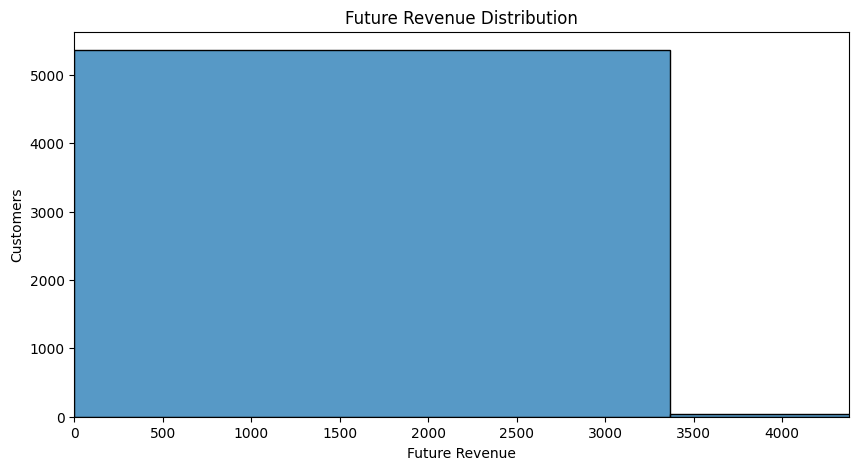

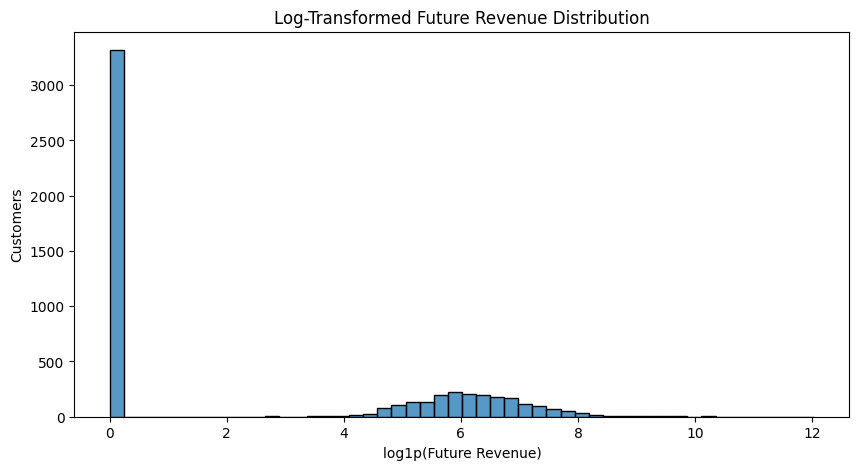


Feature correlation with future revenue:


,Correlation
Monetary,0.585498
Total_Quantity,0.477925
Frequency,0.368116
Unique_Products,0.251597
Avg_Order_Value,0.163430
Customer_Age_Days,0.110801
Recency,-0.106656


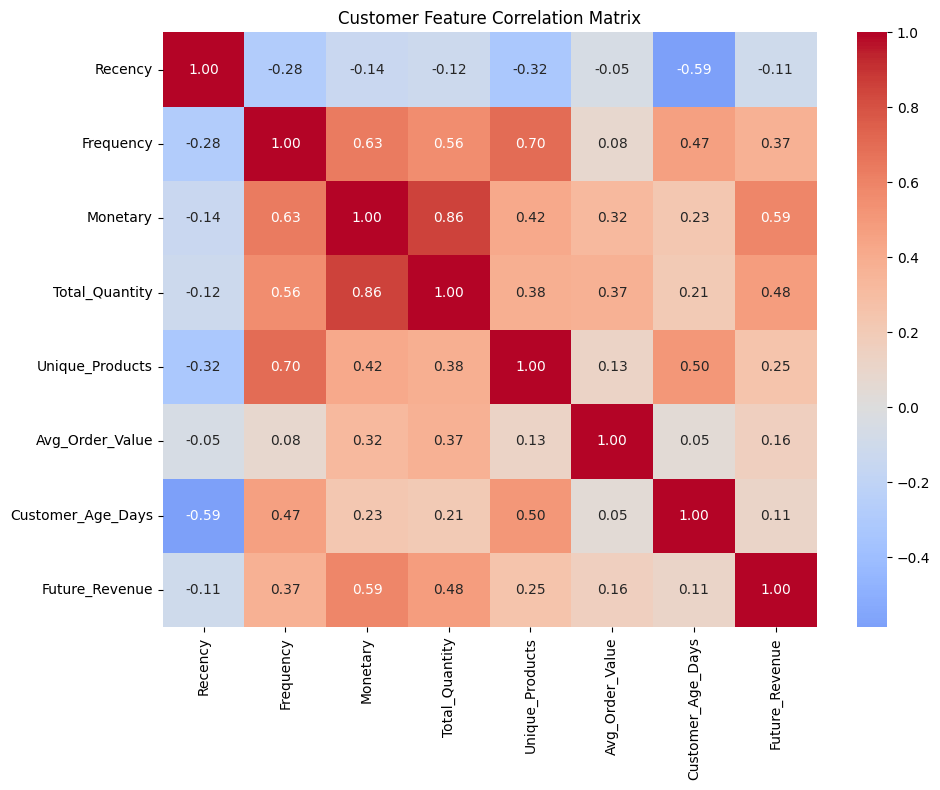


Historical behavior by future purchase status:


,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Avg_Order_Value,Customer_Age_Days
Future_Purchase,,,,,,,
0,266.299578,3.232369,1228.608484,819.370705,47.771549,358.652256,168.281193
1,108.252830,9.849057,4994.917367,2948.601887,119.085849,397.050099,338.088679



Behavioral difference between future buyers and non-buyers:


Future_Purchase,0,1,Difference
Monetary,1228.608484,4994.917367,3766.308883
Total_Quantity,819.370705,2948.601887,2129.231182
Customer_Age_Days,168.281193,338.088679,169.807486
Unique_Products,47.771549,119.085849,71.314300
Avg_Order_Value,358.652256,397.050099,38.397844
Frequency,3.232369,9.849057,6.616688
Recency,266.299578,108.252830,-158.046748



Future revenue concentration:


,Top_Customer_Percentage,Customers,Future_Revenue_Captured_Pct
0,1.0,54,40.916416
1,5.0,271,61.656018
2,10.0,543,74.798362
3,20.0,1087,89.364690
4,50.0,2719,100.000000


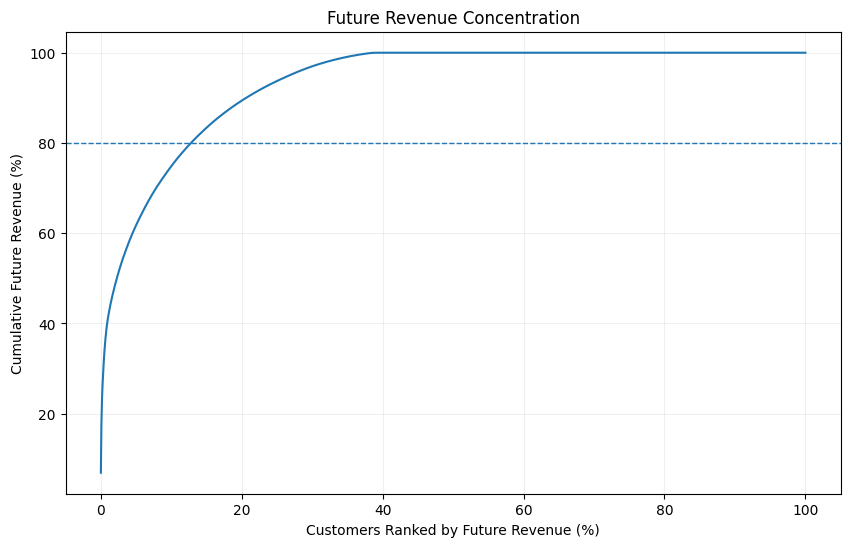


FINAL CLV DIAGNOSTICS
Zero-inflation : 61.02%
Positive target: 38.98%
Target max     : 168,469.60
Target median  : 0.00
Target mean    : 448.56

Recommended modeling approach:
TWO-STAGE / HURDLE MODEL recommended because future revenue contains substantial zero values.


In [7]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 4 — CLV TARGET ANALYSIS & FEATURE DIAGNOSTICS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Validate customer-level dataset
# ------------------------------------------------------------

required_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Unique_Products",
    "Avg_Order_Value",
    "Customer_Age_Days",
    "Future_Revenue",
    "Future_Orders",
    "Future_Quantity"
]

missing_required = [
    col
    for col in required_columns
    if col not in customer_clv.columns
]

if missing_required:

    raise ValueError(
        f"Missing required columns: "
        f"{missing_required}"
    )

# ------------------------------------------------------------
# 2. Target overview
# ------------------------------------------------------------

target = (
    customer_clv[
        "Future_Revenue"
    ]
    .fillna(0)
)

positive_target = (
    target[target > 0]
)

zero_target_count = (
    target.eq(0).sum()
)

positive_target_count = (
    target.gt(0).sum()
)

zero_target_percentage = (
    zero_target_count
    /
    len(target)
    *
    100
)

positive_target_percentage = (
    positive_target_count
    /
    len(target)
    *
    100
)

print("=" * 80)
print("CLV TARGET ANALYSIS")
print("=" * 80)

print(
    f"\nTotal customers          : "
    f"{len(target):,}"
)

print(
    f"Customers with future revenue : "
    f"{positive_target_count:,}"
)

print(
    f"Customers without future revenue : "
    f"{zero_target_count:,}"
)

print(
    f"\nZero-target percentage   : "
    f"{zero_target_percentage:.2f}%"
)

print(
    f"Positive-target percentage : "
    f"{positive_target_percentage:.2f}%"
)

# ------------------------------------------------------------
# 3. Target statistics
# ------------------------------------------------------------

print(
    "\nFuture Revenue statistics:"
)

display(
    target.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame("Future_Revenue")
)

# ------------------------------------------------------------
# 4. Positive future revenue statistics
# ------------------------------------------------------------

print(
    "\nPositive Future Revenue statistics:"
)

if len(positive_target) > 0:

    display(
        positive_target
        .describe(
            percentiles=[
                0.50,
                0.75,
                0.90,
                0.95,
                0.99
            ]
        )
        .to_frame(
            "Positive_Future_Revenue"
        )
    )

# ------------------------------------------------------------
# 5. Log-transformed target diagnostics
# ------------------------------------------------------------

customer_clv[
    "Log_Future_Revenue"
] = np.log1p(
    customer_clv[
        "Future_Revenue"
    ]
)

print(
    "\nLog-transformed target statistics:"
)

display(
    customer_clv[
        "Log_Future_Revenue"
    ]
    .describe()
    .to_frame(
        "Log_Future_Revenue"
    )
)

# ------------------------------------------------------------
# 6. Target distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    target,
    bins=50
)

plt.xlim(
    0,
    target.quantile(0.99)
)

plt.title(
    "Future Revenue Distribution"
)

plt.xlabel(
    "Future Revenue"
)

plt.ylabel(
    "Customers"
)

plt.show()

# ------------------------------------------------------------
# 7. Log target distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    customer_clv[
        "Log_Future_Revenue"
    ],
    bins=50
)

plt.title(
    "Log-Transformed Future Revenue Distribution"
)

plt.xlabel(
    "log1p(Future Revenue)"
)

plt.ylabel(
    "Customers"
)

plt.show()

# ------------------------------------------------------------
# 8. Historical vs future customer behavior
# ------------------------------------------------------------

behavior_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Unique_Products",
    "Avg_Order_Value",
    "Customer_Age_Days"
]

correlation_data = (
    customer_clv[
        behavior_columns
        +
        ["Future_Revenue"]
    ]
    .corr(
        numeric_only=True
    )
)

target_correlation = (
    correlation_data[
        "Future_Revenue"
    ]
    .drop(
        "Future_Revenue"
    )
    .sort_values(
        ascending=False
    )
)

print(
    "\nFeature correlation with future revenue:"
)

display(
    target_correlation
    .to_frame(
        "Correlation"
    )
)

# ------------------------------------------------------------
# 9. Correlation heatmap
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Customer Feature Correlation Matrix"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 10. Compare customers with and without future purchase
# ------------------------------------------------------------

customer_clv[
    "Future_Purchase"
] = (
    customer_clv[
        "Future_Revenue"
    ]
    > 0
).astype(int)

purchase_profile = (
    customer_clv
    .groupby(
        "Future_Purchase"
    )[behavior_columns]
    .mean()
)

print(
    "\nHistorical behavior by future purchase status:"
)

display(
    purchase_profile
)

# ------------------------------------------------------------
# 11. Identify strongest behavioral differences
# ------------------------------------------------------------

profile_difference = (
    purchase_profile
    .T
)

if (
    0 in profile_difference.columns
    and
    1 in profile_difference.columns
):

    profile_difference[
        "Difference"
    ] = (
        profile_difference[1]
        -
        profile_difference[0]
    )

    print(
        "\nBehavioral difference between "
        "future buyers and non-buyers:"
    )

    display(
        profile_difference
        .sort_values(
            "Difference",
            ascending=False
        )
    )

# ------------------------------------------------------------
# 12. Customer value concentration
# ------------------------------------------------------------

sorted_revenue = (
    target
    .sort_values(
        ascending=False
    )
    .reset_index(drop=True)
)

cumulative_revenue = (
    sorted_revenue
    .cumsum()
)

total_future_revenue = (
    sorted_revenue.sum()
)

customer_clv_share = (
    pd.DataFrame({
        "Customer_Rank":
            np.arange(
                1,
                len(sorted_revenue) + 1
            ),
        "Future_Revenue":
            sorted_revenue,
        "Cumulative_Revenue":
            cumulative_revenue
    })
)

customer_clv_share[
    "Cumulative_Revenue_Pct"
] = (
    customer_clv_share[
        "Cumulative_Revenue"
    ]
    /
    total_future_revenue
    *
    100
)

# ------------------------------------------------------------
# 13. Revenue concentration
# ------------------------------------------------------------

concentration_levels = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.50
]

concentration_rows = []

for level in concentration_levels:

    n = max(
        1,
        int(
            len(sorted_revenue)
            * level
        )
    )

    revenue_share = (
        sorted_revenue
        .iloc[:n]
        .sum()
        /
        total_future_revenue
        *
        100
    )

    concentration_rows.append({
        "Top_Customer_Percentage":
            level * 100,
        "Customers":
            n,
        "Future_Revenue_Captured_Pct":
            revenue_share
    })

concentration_report = pd.DataFrame(
    concentration_rows
)

print(
    "\nFuture revenue concentration:"
)

display(
    concentration_report
)

# ------------------------------------------------------------
# 14. Pareto-style visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

customer_percentage = (
    customer_clv_share[
        "Customer_Rank"
    ]
    /
    len(customer_clv_share)
    *
    100
)

plt.plot(
    customer_percentage,
    customer_clv_share[
        "Cumulative_Revenue_Pct"
    ]
)

plt.axhline(
    80,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Customers Ranked by Future Revenue (%)"
)

plt.ylabel(
    "Cumulative Future Revenue (%)"
)

plt.title(
    "Future Revenue Concentration"
)

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 15. Final diagnostics
# ------------------------------------------------------------

print(
    "\n" + "=" * 80
)

print(
    "FINAL CLV DIAGNOSTICS"
)

print(
    "=" * 80
)

print(
    f"Zero-inflation : "
    f"{zero_target_percentage:.2f}%"
)

print(
    f"Positive target: "
    f"{positive_target_percentage:.2f}%"
)

print(
    f"Target max     : "
    f"{target.max():,.2f}"
)

print(
    f"Target median  : "
    f"{target.median():,.2f}"
)

print(
    f"Target mean    : "
    f"{target.mean():,.2f}"
)

print(
    "\nRecommended modeling approach:"
)

if zero_target_percentage > 30:

    print(
        "TWO-STAGE / HURDLE MODEL "
        "recommended because future revenue "
        "contains substantial zero values."
    )

else:

    print(
        "Single-stage regression may be sufficient, "
        "but target transformation should still be evaluated."
    )


Training Stage 1: Logistic Regression

Training Stage 1: Random Forest

Training Stage 1: XGBoost

STAGE 1 — FUTURE PURCHASE PREDICTION


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.740809,0.658482,0.695755,0.676606,0.810628
1,Logistic Regression,0.723346,0.619417,0.752358,0.679446,0.809776
2,XGBoost,0.727941,0.681818,0.566038,0.618557,0.794438



Best Stage 1 model: Random Forest

Training Stage 2: Random Forest

Training Stage 2: Gradient Boosting

Training Stage 2: XGBoost

STAGE 2 — CONDITIONAL FUTURE REVENUE


,Model,MAE,RMSE,R2
0,Gradient Boosting,501.794155,2219.664025,0.669466
1,Random Forest,506.091138,2586.362608,0.551234
2,XGBoost,554.955754,2709.017567,0.507660



Best Stage 2 model: Gradient Boosting

FINAL TWO-STAGE CLV MODEL

Stage 1 model : Random Forest
Stage 2 model : Gradient Boosting

Final MAE     : 335.19
Final RMSE    : 1,575.68
Final R²      : 0.5889

Top 10% CLV ranking captures 58.78% of actual future revenue.

Top 20 customers by predicted CLV:


,CustomerID,Actual_Future_Revenue,Actual_Future_Purchase,Purchase_Probability,Conditional_Revenue,Predicted_CLV
CustomerID,,,,,,
14646.0,14646.0,77099.38,1,0.977258,33835.142075,33065.673937
16738.0,16738.0,0.00,0,0.157381,130773.688925,20581.247753
13408.0,13408.0,7735.46,1,0.989315,5883.253881,5820.394204
14298.0,14298.0,7289.84,1,0.982266,5730.976855,5629.341698
13081.0,13081.0,9467.26,1,0.837319,6668.213752,5583.424635
17675.0,17675.0,5249.11,1,0.989520,5611.447204,5552.638504
15098.0,15098.0,0.00,0,0.450299,11829.080666,5326.623917
12409.0,12409.0,0.00,0,0.783117,4534.649868,3551.162144
13340.0,13340.0,1506.94,1,0.821415,4062.741992,3337.197216


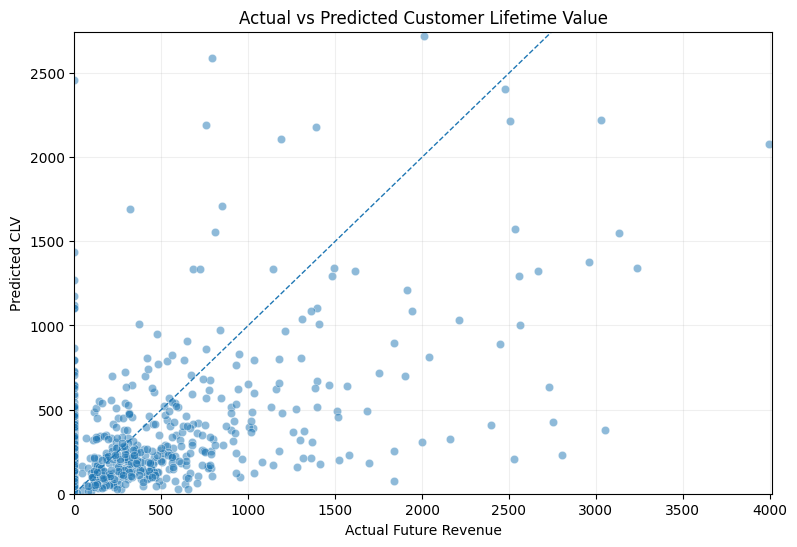

In [8]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 5 — TWO-STAGE CLV MODELING
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# XGBoost
try:

    from xgboost import (
        XGBClassifier,
        XGBRegressor
    )

    xgb_available = True

except ImportError:

    xgb_available = False

# ------------------------------------------------------------
# 1. Define features
# ------------------------------------------------------------

feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Unique_Products",
    "Avg_Order_Value",
    "Customer_Age_Days",
    "Log_Monetary",
    "Log_Frequency",
    "Log_Avg_Order_Value"
]

# ------------------------------------------------------------
# 2. Prepare dataset
# ------------------------------------------------------------

model_data = (
    customer_clv[
        feature_columns
        +
        [
            "Future_Revenue",
            "Future_Purchase"
        ]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .copy()
)

X = (
    model_data[
        feature_columns
    ]
)

y_purchase = (
    model_data[
        "Future_Purchase"
    ]
)

y_revenue = (
    model_data[
        "Future_Revenue"
    ]
)

# ------------------------------------------------------------
# 3. Time-aware train/test split
# ------------------------------------------------------------

# The customer-level dataset is already created from
# a historical observation period and a future target period.
# We now split customers into train/test while keeping
# the target period untouched.

X_train, X_test, y_purchase_train, y_purchase_test = (
    train_test_split(
        X,
        y_purchase,
        test_size=0.20,
        random_state=42,
        stratify=y_purchase
    )
)

y_revenue_train = (
    y_revenue.loc[
        X_train.index
    ]
)

y_revenue_test = (
    y_revenue.loc[
        X_test.index
    ]
)

# ------------------------------------------------------------
# 4. Stage 1 — purchase probability models
# ------------------------------------------------------------

stage1_models = {
    "Logistic Regression":
        Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
}

if xgb_available:

    stage1_models[
        "XGBoost"
    ] = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

# ------------------------------------------------------------
# 5. Evaluate Stage 1
# ------------------------------------------------------------

stage1_results = []

trained_stage1 = {}

for name, model in stage1_models.items():

    print(
        f"\nTraining Stage 1: {name}"
    )

    model.fit(
        X_train,
        y_purchase_train
    )

    y_pred = (
        model.predict(
            X_test
        )
    )

    y_prob = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    metrics = {
        "Model": name,
        "Accuracy":
            accuracy_score(
                y_purchase_test,
                y_pred
            ),
        "Precision":
            precision_score(
                y_purchase_test,
                y_pred,
                zero_division=0
            ),
        "Recall":
            recall_score(
                y_purchase_test,
                y_pred,
                zero_division=0
            ),
        "F1":
            f1_score(
                y_purchase_test,
                y_pred,
                zero_division=0
            ),
        "ROC_AUC":
            roc_auc_score(
                y_purchase_test,
                y_prob
            )
    }

    stage1_results.append(
        metrics
    )

    trained_stage1[
        name
    ] = model

stage1_comparison = (
    pd.DataFrame(
        stage1_results
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\n" + "=" * 80
)

print(
    "STAGE 1 — FUTURE PURCHASE PREDICTION"
)

print(
    "=" * 80
)

display(
    stage1_comparison
)

# ------------------------------------------------------------
# 6. Select best Stage 1 model
# ------------------------------------------------------------

best_stage1_name = (
    stage1_comparison
    .iloc[0]["Model"]
)

best_stage1_model = (
    trained_stage1[
        best_stage1_name
    ]
)

purchase_probability_test = (
    best_stage1_model
    .predict_proba(
        X_test
    )[:, 1]
)

print(
    f"\nBest Stage 1 model: "
    f"{best_stage1_name}"
)

# ------------------------------------------------------------
# 7. Stage 2 dataset
# ------------------------------------------------------------

# Only customers with positive future revenue
# are used for conditional revenue modeling.

positive_train_mask = (
    y_revenue_train > 0
)

X_train_revenue = (
    X_train.loc[
        positive_train_mask
    ]
)

y_train_revenue = (
    y_revenue_train.loc[
        positive_train_mask
    ]
)

# Log-transform revenue to reduce extreme skewness
y_train_revenue_log = np.log1p(
    y_train_revenue
)

# ------------------------------------------------------------
# 8. Stage 2 — conditional revenue models
# ------------------------------------------------------------

stage2_models = {

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            random_state=42
        )
}

if xgb_available:

    stage2_models[
        "XGBoost"
    ] = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

# ------------------------------------------------------------
# 9. Evaluate Stage 2
# ------------------------------------------------------------

stage2_results = []

trained_stage2 = {}

# Only evaluate actual future buyers
positive_test_mask = (
    y_revenue_test > 0
)

X_test_positive = (
    X_test.loc[
        positive_test_mask
    ]
)

y_test_positive = (
    y_revenue_test.loc[
        positive_test_mask
    ]
)

for name, model in stage2_models.items():

    print(
        f"\nTraining Stage 2: {name}"
    )

    model.fit(
        X_train_revenue,
        y_train_revenue_log
    )

    prediction_log = (
        model.predict(
            X_test_positive
        )
    )

    prediction_revenue = (
        np.expm1(
            prediction_log
        )
    )

    prediction_revenue = np.clip(
        prediction_revenue,
        0,
        None
    )

    mae = mean_absolute_error(
        y_test_positive,
        prediction_revenue
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_positive,
            prediction_revenue
        )
    )

    r2 = r2_score(
        y_test_positive,
        prediction_revenue
    )

    stage2_results.append({
        "Model": name,
        "MAE":
            mae,
        "RMSE":
            rmse,
        "R2":
            r2
    })

    trained_stage2[
        name
    ] = model

stage2_comparison = (
    pd.DataFrame(
        stage2_results
    )
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print(
    "\n" + "=" * 80
)

print(
    "STAGE 2 — CONDITIONAL FUTURE REVENUE"
)

print(
    "=" * 80
)

display(
    stage2_comparison
)

# ------------------------------------------------------------
# 10. Select best Stage 2 model
# ------------------------------------------------------------

best_stage2_name = (
    stage2_comparison
    .iloc[0]["Model"]
)

best_stage2_model = (
    trained_stage2[
        best_stage2_name
    ]
)

print(
    f"\nBest Stage 2 model: "
    f"{best_stage2_name}"
)

# ------------------------------------------------------------
# 11. Predict conditional revenue for ALL test customers
# ------------------------------------------------------------

conditional_revenue_log = (
    best_stage2_model
    .predict(
        X_test
    )
)

conditional_revenue = (
    np.expm1(
        conditional_revenue_log
    )
)

conditional_revenue = np.clip(
    conditional_revenue,
    0,
    None
)

# ------------------------------------------------------------
# 12. Calculate expected CLV
# ------------------------------------------------------------

predicted_clv = (
    purchase_probability_test
    *
    conditional_revenue
)

# ------------------------------------------------------------
# 13. Create prediction dataframe
# ------------------------------------------------------------

clv_predictions = pd.DataFrame(
    {
        "CustomerID":
            customer_clv.loc[
                X_test.index
            ].index,

        "Actual_Future_Revenue":
            y_revenue_test.values,

        "Actual_Future_Purchase":
            y_purchase.loc[
                X_test.index
            ].values,

        "Purchase_Probability":
            purchase_probability_test,

        "Conditional_Revenue":
            conditional_revenue,

        "Predicted_CLV":
            predicted_clv
    },
    index=X_test.index
)

# ------------------------------------------------------------
# 14. Evaluate final CLV prediction
# ------------------------------------------------------------

final_mae = mean_absolute_error(
    clv_predictions[
        "Actual_Future_Revenue"
    ],
    clv_predictions[
        "Predicted_CLV"
    ]
)

final_rmse = np.sqrt(
    mean_squared_error(
        clv_predictions[
            "Actual_Future_Revenue"
        ],
        clv_predictions[
            "Predicted_CLV"
        ]
    )
)

final_r2 = r2_score(
    clv_predictions[
        "Actual_Future_Revenue"
    ],
    clv_predictions[
        "Predicted_CLV"
    ]
)

# ------------------------------------------------------------
# 15. Revenue concentration metrics
# ------------------------------------------------------------

actual_sorted = (
    clv_predictions
    .sort_values(
        "Actual_Future_Revenue",
        ascending=False
    )
)

predicted_sorted = (
    clv_predictions
    .sort_values(
        "Predicted_CLV",
        ascending=False
    )
)

# ------------------------------------------------------------
# 16. Top 10% CLV capture
# ------------------------------------------------------------

n_top = max(
    1,
    int(
        len(clv_predictions)
        * 0.10
    )
)

actual_total_revenue = (
    clv_predictions[
        "Actual_Future_Revenue"
    ]
    .sum()
)

top10_actual_revenue = (
    predicted_sorted
    .head(n_top)[
        "Actual_Future_Revenue"
    ]
    .sum()
)

top10_revenue_capture = (
    top10_actual_revenue
    /
    actual_total_revenue
    *
    100
    if actual_total_revenue > 0
    else 0
)

# ------------------------------------------------------------
# 17. Display final results
# ------------------------------------------------------------

print(
    "\n" + "=" * 80
)

print(
    "FINAL TWO-STAGE CLV MODEL"
)

print(
    "=" * 80
)

print(
    f"\nStage 1 model : "
    f"{best_stage1_name}"
)

print(
    f"Stage 2 model : "
    f"{best_stage2_name}"
)

print(
    f"\nFinal MAE     : "
    f"{final_mae:,.2f}"
)

print(
    f"Final RMSE    : "
    f"{final_rmse:,.2f}"
)

print(
    f"Final R²      : "
    f"{final_r2:.4f}"
)

print(
    f"\nTop 10% CLV ranking captures "
    f"{top10_revenue_capture:.2f}% "
    f"of actual future revenue."
)

# ------------------------------------------------------------
# 18. Top predicted customers
# ------------------------------------------------------------

print(
    "\nTop 20 customers by predicted CLV:"
)

display(
    clv_predictions
    .sort_values(
        "Predicted_CLV",
        ascending=False
    )
    .head(20)
)

# ------------------------------------------------------------
# 19. Predicted vs actual
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(
    figsize=(9, 6)
)

sns.scatterplot(
    data=clv_predictions,
    x="Actual_Future_Revenue",
    y="Predicted_CLV",
    alpha=0.5
)

max_value = max(
    clv_predictions[
        "Actual_Future_Revenue"
    ].max(),
    clv_predictions[
        "Predicted_CLV"
    ].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=1
)

plt.xlim(
    0,
    np.quantile(
        clv_predictions[
            "Actual_Future_Revenue"
        ],
        0.99
    )
)

plt.ylim(
    0,
    np.quantile(
        clv_predictions[
            "Predicted_CLV"
        ],
        0.99
    )
)

plt.title(
    "Actual vs Predicted Customer Lifetime Value"
)

plt.xlabel(
    "Actual Future Revenue"
)

plt.ylabel(
    "Predicted CLV"
)

plt.grid(
    alpha=0.2
)

plt.show()

CLV RANKING & REVENUE CAPTURE


,Targeting,Customers,Actual_Revenue_Captured,Revenue_Capture_Pct,Random_Benchmark_Pct,Lift_vs_Random,Average_Revenue_per_Customer
0,1%,10,111803.07,26.770643,1.0,26.770643,11180.307000
1,5%,54,199882.06,47.860682,5.0,9.572136,3701.519630
2,10%,108,245472.02,58.776952,10.0,5.877695,2272.889074
3,20%,217,298733.55,71.530139,20.0,3.576507,1376.652304
4,30%,326,327327.23,78.376741,30.0,2.612558,1004.071258
5,50%,544,383746.73,91.886087,50.0,1.837722,705.416783
6,100%,1088,417633.12,100.000000,100.0,1.000000,383.853971



RANKING CORRELATION
Spearman correlation : 0.5226
P-value              : 2.713470e-77

Actual high-value threshold:
456.44

HIGH-VALUE CUSTOMER PRECISION


,Targeting,Customers,High_Value_Customers,High_Value_Precision_Pct
0,1%,10,7,70.000000
1,5%,54,42,77.777778
2,10%,108,77,71.296296
3,20%,217,126,58.064516
4,30%,326,150,46.012270



TOP 10% BUSINESS VALUE
Customers targeted      : 108
Actual revenue captured : 245,472.02
Revenue captured        : 58.78%
Random benchmark        : 10.00%
Lift vs random          : 5.88x


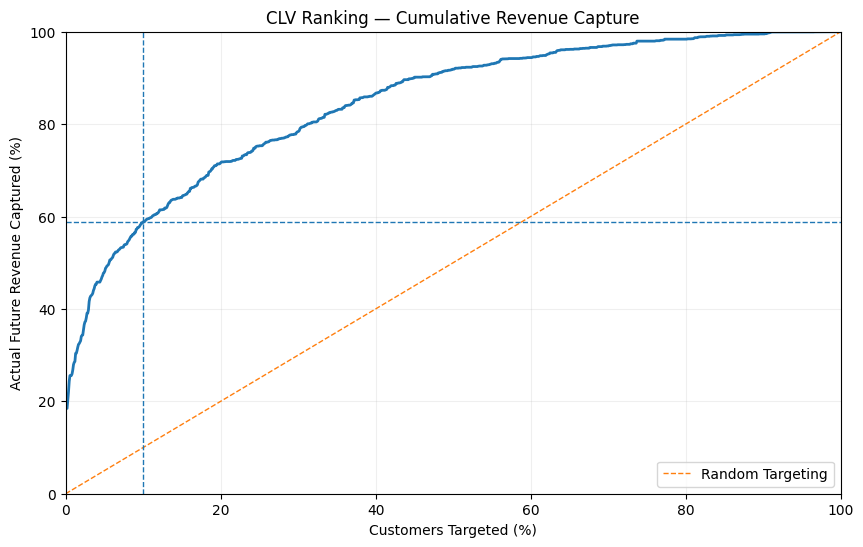

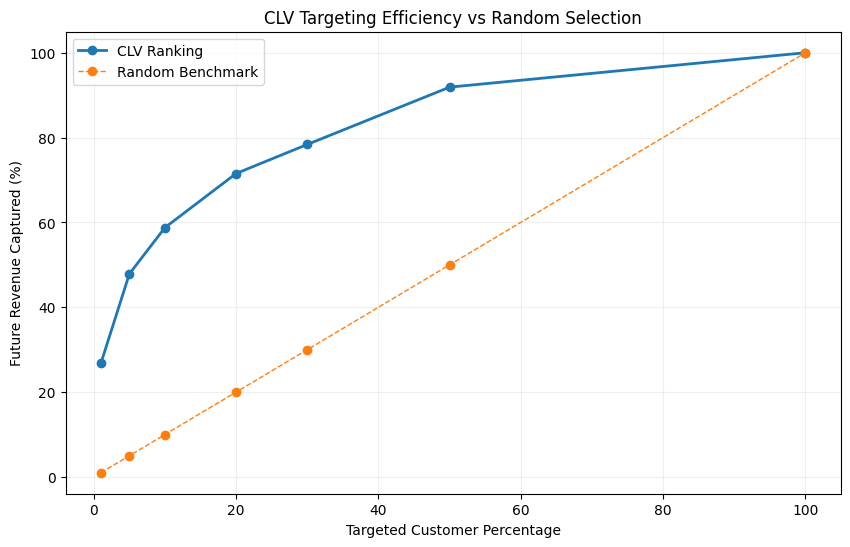


FINAL RANKING EVALUATION
Top 10% revenue capture : 58.78%
Random benchmark        : 10.00%
Lift vs random          : 5.88x
Spearman correlation    : 0.5226


In [9]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 6 — CLV RANKING & BUSINESS VALUE EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

# ------------------------------------------------------------
# 1. Validate prediction dataset
# ------------------------------------------------------------

required_prediction_columns = [
    "Actual_Future_Revenue",
    "Predicted_CLV"
]

missing_columns = [
    col
    for col in required_prediction_columns
    if col not in clv_predictions.columns
]

if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ------------------------------------------------------------
# 2. Rank customers by predicted CLV
# ------------------------------------------------------------

ranking_df = (
    clv_predictions[
        [
            "Actual_Future_Revenue",
            "Predicted_CLV"
        ]
    ]
    .copy()
)

ranking_df = (
    ranking_df
    .sort_values(
        "Predicted_CLV",
        ascending=False
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Calculate total actual future revenue
# ------------------------------------------------------------

total_actual_revenue = (
    ranking_df[
        "Actual_Future_Revenue"
    ]
    .sum()
)

total_customers = (
    len(ranking_df)
)

# ------------------------------------------------------------
# 4. Define targeting levels
# ------------------------------------------------------------

targeting_levels = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
    1.00
]

ranking_results = []

for level in targeting_levels:

    n_target = max(
        1,
        int(
            total_customers
            *
            level
        )
    )

    selected = (
        ranking_df
        .head(
            n_target
        )
    )

    actual_revenue_captured = (
        selected[
            "Actual_Future_Revenue"
        ]
        .sum()
    )

    revenue_capture = (
        actual_revenue_captured
        /
        total_actual_revenue
        *
        100
        if total_actual_revenue > 0
        else 0
    )

    random_expected_capture = (
        level * 100
    )

    lift_over_random = (
        revenue_capture
        /
        random_expected_capture
        if random_expected_capture > 0
        else np.nan
    )

    average_actual_revenue = (
        selected[
            "Actual_Future_Revenue"
        ]
        .mean()
    )

    ranking_results.append({
        "Targeting": f"{int(level * 100)}%",
        "Customers": n_target,
        "Actual_Revenue_Captured":
            actual_revenue_captured,
        "Revenue_Capture_Pct":
            revenue_capture,
        "Random_Benchmark_Pct":
            random_expected_capture,
        "Lift_vs_Random":
            lift_over_random,
        "Average_Revenue_per_Customer":
            average_actual_revenue
    })

ranking_report = (
    pd.DataFrame(
        ranking_results
    )
)

# ------------------------------------------------------------
# 5. Calculate revenue concentration
# ------------------------------------------------------------

print("=" * 90)
print("CLV RANKING & REVENUE CAPTURE")
print("=" * 90)

display(
    ranking_report
)

# ------------------------------------------------------------
# 6. Spearman rank correlation
# ------------------------------------------------------------

spearman_correlation, spearman_pvalue = (
    spearmanr(
        ranking_df[
            "Predicted_CLV"
        ],
        ranking_df[
            "Actual_Future_Revenue"
        ]
    )
)

print(
    "\n" + "=" * 90
)

print(
    "RANKING CORRELATION"
)

print(
    "=" * 90
)

print(
    f"Spearman correlation : "
    f"{spearman_correlation:.4f}"
)

print(
    f"P-value              : "
    f"{spearman_pvalue:.6e}"
)

# ------------------------------------------------------------
# 7. High-value customer identification
# ------------------------------------------------------------

high_value_threshold = (
    ranking_df[
        "Actual_Future_Revenue"
    ]
    .quantile(
        0.80
    )
)

ranking_df[
    "Actual_High_Value"
] = (
    ranking_df[
        "Actual_Future_Revenue"
    ]
    >=
    high_value_threshold
).astype(int)

print(
    "\nActual high-value threshold:"
)

print(
    f"{high_value_threshold:,.2f}"
)

# ------------------------------------------------------------
# 8. Precision of high-value customers
# ------------------------------------------------------------

high_value_results = []

for level in [
    0.01,
    0.05,
    0.10,
    0.20,
    0.30
]:

    n_target = max(
        1,
        int(
            total_customers
            *
            level
        )
    )

    selected = (
        ranking_df
        .head(
            n_target
        )
    )

    precision_high_value = (
        selected[
            "Actual_High_Value"
        ]
        .mean()
        *
        100
    )

    high_value_results.append({
        "Targeting":
            f"{int(level * 100)}%",
        "Customers":
            n_target,
        "High_Value_Customers":
            int(
                selected[
                    "Actual_High_Value"
                ].sum()
            ),
        "High_Value_Precision_Pct":
            precision_high_value
    })

high_value_report = pd.DataFrame(
    high_value_results
)

print(
    "\n" + "=" * 90
)

print(
    "HIGH-VALUE CUSTOMER PRECISION"
)

print(
    "=" * 90
)

display(
    high_value_report
)

# ------------------------------------------------------------
# 9. Top 10% detailed analysis
# ------------------------------------------------------------

top10_n = max(
    1,
    int(
        total_customers
        *
        0.10
    )
)

top10_customers = (
    ranking_df
    .head(
        top10_n
    )
)

top10_revenue = (
    top10_customers[
        "Actual_Future_Revenue"
    ]
    .sum()
)

top10_capture = (
    top10_revenue
    /
    total_actual_revenue
    *
    100
)

top10_lift = (
    top10_capture
    /
    10
)

print(
    "\n" + "=" * 90
)

print(
    "TOP 10% BUSINESS VALUE"
)

print(
    "=" * 90
)

print(
    f"Customers targeted      : "
    f"{top10_n:,}"
)

print(
    f"Actual revenue captured : "
    f"{top10_revenue:,.2f}"
)

print(
    f"Revenue captured        : "
    f"{top10_capture:.2f}%"
)

print(
    f"Random benchmark        : "
    f"10.00%"
)

print(
    f"Lift vs random          : "
    f"{top10_lift:.2f}x"
)

# ------------------------------------------------------------
# 10. Cumulative revenue capture curve
# ------------------------------------------------------------

ranking_df[
    "Cumulative_Revenue"
] = (
    ranking_df[
        "Actual_Future_Revenue"
    ]
    .cumsum()
)

ranking_df[
    "Cumulative_Revenue_Pct"
] = (
    ranking_df[
        "Cumulative_Revenue"
    ]
    /
    total_actual_revenue
    *
    100
)

ranking_df[
    "Customer_Percentage"
] = (
    np.arange(
        1,
        total_customers + 1
    )
    /
    total_customers
    *
    100
)

# ------------------------------------------------------------
# 11. Plot cumulative revenue capture
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    ranking_df[
        "Customer_Percentage"
    ],
    ranking_df[
        "Cumulative_Revenue_Pct"
    ],
    linewidth=2
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1,
    label="Random Targeting"
)

plt.axvline(
    10,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    top10_capture,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Customers Targeted (%)"
)

plt.ylabel(
    "Actual Future Revenue Captured (%)"
)

plt.title(
    "CLV Ranking — Cumulative Revenue Capture"
)

plt.xlim(
    0,
    100
)

plt.ylim(
    0,
    100
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 12. Revenue capture vs random
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plot_df = ranking_report.copy()

plot_df[
    "Targeting_Numeric"
] = (
    plot_df[
        "Targeting"
    ]
    .str.replace(
        "%",
        "",
        regex=False
    )
    .astype(float)
)

plt.plot(
    plot_df[
        "Targeting_Numeric"
    ],
    plot_df[
        "Revenue_Capture_Pct"
    ],
    marker="o",
    linewidth=2,
    label="CLV Ranking"
)

plt.plot(
    plot_df[
        "Targeting_Numeric"
    ],
    plot_df[
        "Random_Benchmark_Pct"
    ],
    marker="o",
    linestyle="--",
    linewidth=1,
    label="Random Benchmark"
)

plt.xlabel(
    "Targeted Customer Percentage"
)

plt.ylabel(
    "Future Revenue Captured (%)"
)

plt.title(
    "CLV Targeting Efficiency vs Random Selection"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 13. Final ranking evaluation
# ------------------------------------------------------------

best_targeting_row = (
    ranking_report[
        ranking_report[
            "Targeting"
        ] == "10%"
    ]
    .iloc[0]
)

print(
    "\n" + "=" * 90
)

print(
    "FINAL RANKING EVALUATION"
)

print(
    "=" * 90
)

print(
    f"Top 10% revenue capture : "
    f"{best_targeting_row['Revenue_Capture_Pct']:.2f}%"
)

print(
    f"Random benchmark        : "
    f"{best_targeting_row['Random_Benchmark_Pct']:.2f}%"
)

print(
    f"Lift vs random          : "
    f"{best_targeting_row['Lift_vs_Random']:.2f}x"
)

print(
    f"Spearman correlation    : "
    f"{spearman_correlation:.4f}"
)

CUSTOMER VALUE SEGMENTATION

CLV thresholds:
25th percentile : 73.88
50th percentile : 144.90
75th percentile : 301.44

Segment Summary:


,Customers,Avg_Predicted_CLV,Median_Predicted_CLV,Total_Predicted_CLV,Avg_Actual_Revenue,Total_Actual_Revenue,Customer_Pct,Actual_Revenue_Pct
CLV_Segment,,,,,,,,
Low Value,272,39.422108,36.840594,10722.813342,31.226434,8493.59,25.0,2.033744
Medium Value,272,106.786898,103.446199,29046.036350,93.355882,25392.80,25.0,6.080169
High Value,272,208.847283,203.857251,56806.460945,254.351140,69183.51,25.0,16.565619
VIP Value,272,994.316638,509.386795,270454.125464,1156.482426,314563.22,25.0,75.320468



Recommended Business Actions:


,Segment,Recommended_Action
0,Low Value,Low-cost automated engagement
1,Medium Value,Personalized cross-sell / upsell
2,High Value,Retention and premium offers
3,VIP Value,Priority retention and high-value service



REVENUE CONCENTRATION BY CLV SEGMENT


,Customers,Customer_Pct,Total_Predicted_CLV,Total_Actual_Revenue,Actual_Revenue_Pct
CLV_Segment,,,,,
Low Value,272,25.0,10722.813342,8493.59,2.033744
Medium Value,272,25.0,29046.036350,25392.80,6.080169
High Value,272,25.0,56806.460945,69183.51,16.565619
VIP Value,272,25.0,270454.125464,314563.22,75.320468



High + VIP Value Customers:
Customers        : 544
Population share : 50.00%
Revenue captured : 91.89%

Actual future revenue by predicted CLV segment:


,count,mean,median,sum
CLV_Segment,,,,
Low Value,272,31.226434,0.000,8493.59
Medium Value,272,93.355882,0.000,25392.80
High Value,272,254.351140,0.000,69183.51
VIP Value,272,1156.482426,479.325,314563.22


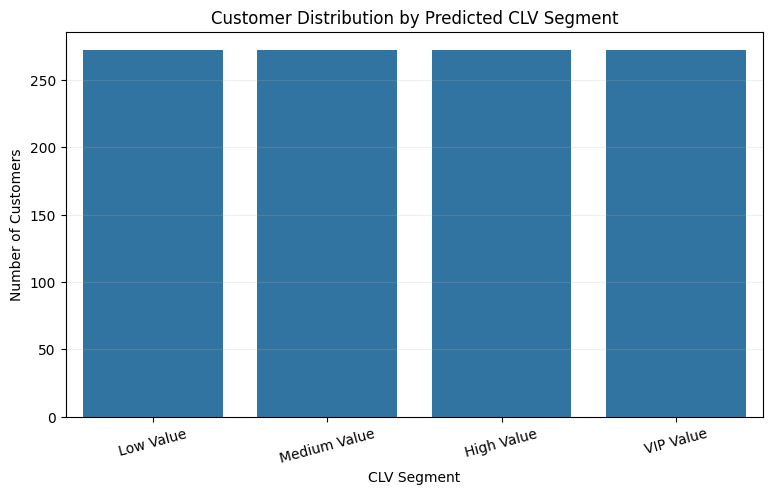

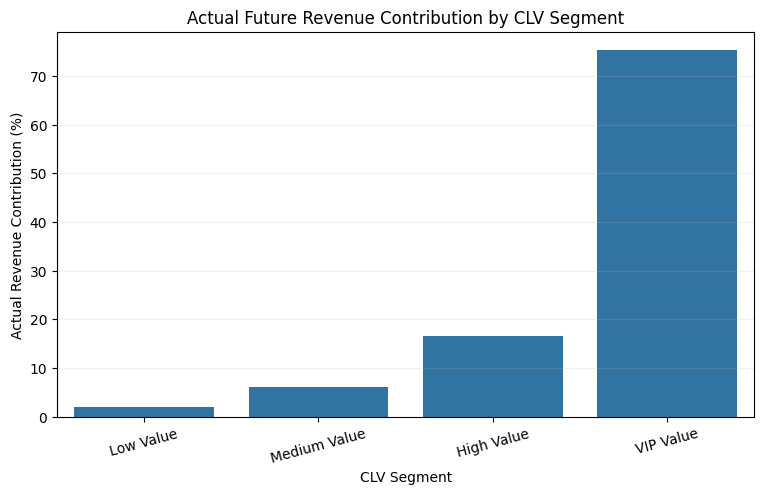

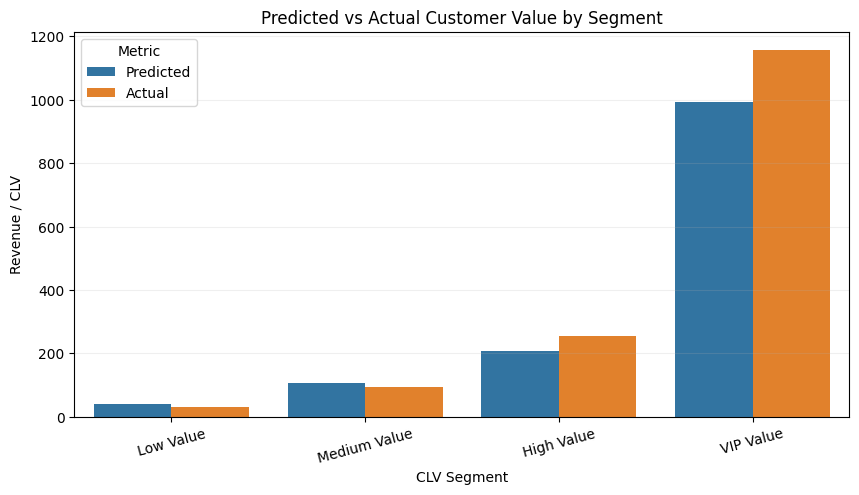


Top 20 customers with recommended actions:


,Actual_Future_Revenue,Purchase_Probability,Conditional_Revenue,Predicted_CLV,CLV_Segment,Recommended_Action
CustomerID,,,,,,
14646.0,77099.38,0.977258,33835.142075,33065.673937,VIP Value,Priority retention and high-value service
16738.0,0.00,0.157381,130773.688925,20581.247753,VIP Value,Priority retention and high-value service
13408.0,7735.46,0.989315,5883.253881,5820.394204,VIP Value,Priority retention and high-value service
14298.0,7289.84,0.982266,5730.976855,5629.341698,VIP Value,Priority retention and high-value service
13081.0,9467.26,0.837319,6668.213752,5583.424635,VIP Value,Priority retention and high-value service
17675.0,5249.11,0.989520,5611.447204,5552.638504,VIP Value,Priority retention and high-value service
15098.0,0.00,0.450299,11829.080666,5326.623917,VIP Value,Priority retention and high-value service
12409.0,0.00,0.783117,4534.649868,3551.162144,VIP Value,Priority retention and high-value service
13340.0,1506.94,0.821415,4062.741992,3337.197216,VIP Value,Priority retention and high-value service



SEGMENTATION INTERPRETATION
High + VIP segments represent 50.00% of customers and account for 91.89% of actual future revenue.

This segmentation can be used to prioritize customer retention, personalization, and high-value marketing activities.


In [10]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 7 — CUSTOMER VALUE SEGMENTATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Validate CLV predictions
# ------------------------------------------------------------

if "Predicted_CLV" not in clv_predictions.columns:
    raise ValueError(
        "Kolom Predicted_CLV tidak ditemukan."
    )

segment_df = (
    clv_predictions
    .copy()
)

# ------------------------------------------------------------
# 2. Create CLV percentile thresholds
# ------------------------------------------------------------

q25 = (
    segment_df[
        "Predicted_CLV"
    ]
    .quantile(0.25)
)

q50 = (
    segment_df[
        "Predicted_CLV"
    ]
    .quantile(0.50)
)

q75 = (
    segment_df[
        "Predicted_CLV"
    ]
    .quantile(0.75)
)

# ------------------------------------------------------------
# 3. Assign customer value segment
# ------------------------------------------------------------

def assign_segment(clv):

    if clv <= q25:

        return "Low Value"

    elif clv <= q50:

        return "Medium Value"

    elif clv <= q75:

        return "High Value"

    else:

        return "VIP Value"

segment_df[
    "CLV_Segment"
] = (
    segment_df[
        "Predicted_CLV"
    ]
    .apply(
        assign_segment
    )
)

# ------------------------------------------------------------
# 4. Recommended business action
# ------------------------------------------------------------

def recommended_action(segment):

    actions = {

        "Low Value":
            "Low-cost automated engagement",

        "Medium Value":
            "Personalized cross-sell / upsell",

        "High Value":
            "Retention and premium offers",

        "VIP Value":
            "Priority retention and high-value service"
    }

    return actions[
        segment
    ]

segment_df[
    "Recommended_Action"
] = (
    segment_df[
        "CLV_Segment"
    ]
    .apply(
        recommended_action
    )
)

# ------------------------------------------------------------
# 5. Segment statistics
# ------------------------------------------------------------

segment_order = [
    "Low Value",
    "Medium Value",
    "High Value",
    "VIP Value"
]

segment_summary = (
    segment_df
    .groupby(
        "CLV_Segment"
    )
    .agg(
        Customers=(
            "Predicted_CLV",
            "count"
        ),
        Avg_Predicted_CLV=(
            "Predicted_CLV",
            "mean"
        ),
        Median_Predicted_CLV=(
            "Predicted_CLV",
            "median"
        ),
        Total_Predicted_CLV=(
            "Predicted_CLV",
            "sum"
        ),
        Avg_Actual_Revenue=(
            "Actual_Future_Revenue",
            "mean"
        ),
        Total_Actual_Revenue=(
            "Actual_Future_Revenue",
            "sum"
        )
    )
    .reindex(
        segment_order
    )
)

# ------------------------------------------------------------
# 6. Percentage of customer population
# ------------------------------------------------------------

segment_summary[
    "Customer_Pct"
] = (
    segment_summary[
        "Customers"
    ]
    /
    len(segment_df)
    *
    100
)

# ------------------------------------------------------------
# 7. Percentage of actual revenue
# ------------------------------------------------------------

total_actual_revenue = (
    segment_summary[
        "Total_Actual_Revenue"
    ]
    .sum()
)

segment_summary[
    "Actual_Revenue_Pct"
] = (
    segment_summary[
        "Total_Actual_Revenue"
    ]
    /
    total_actual_revenue
    *
    100
)

# ------------------------------------------------------------
# 8. Display segment summary
# ------------------------------------------------------------

print("=" * 90)
print("CUSTOMER VALUE SEGMENTATION")
print("=" * 90)

print(
    f"\nCLV thresholds:"
)

print(
    f"25th percentile : "
    f"{q25:,.2f}"
)

print(
    f"50th percentile : "
    f"{q50:,.2f}"
)

print(
    f"75th percentile : "
    f"{q75:,.2f}"
)

print(
    "\nSegment Summary:"
)

display(
    segment_summary
)

# ------------------------------------------------------------
# 9. Segment action table
# ------------------------------------------------------------

action_table = pd.DataFrame({
    "Segment":
        segment_order,
    "Recommended_Action": [
        recommended_action(
            segment
        )
        for segment in segment_order
    ]
})

print(
    "\nRecommended Business Actions:"
)

display(
    action_table
)

# ------------------------------------------------------------
# 10. Revenue concentration by segment
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "REVENUE CONCENTRATION BY CLV SEGMENT"
)

print(
    "=" * 90
)

display(
    segment_summary[
        [
            "Customers",
            "Customer_Pct",
            "Total_Predicted_CLV",
            "Total_Actual_Revenue",
            "Actual_Revenue_Pct"
        ]
    ]
)

# ------------------------------------------------------------
# 11. High-value population
# ------------------------------------------------------------

high_value_customers = (
    segment_df[
        segment_df[
            "CLV_Segment"
        ].isin(
            [
                "High Value",
                "VIP Value"
            ]
        )
    ]
)

high_value_customer_pct = (
    len(high_value_customers)
    /
    len(segment_df)
    *
    100
)

high_value_revenue = (
    high_value_customers[
        "Actual_Future_Revenue"
    ]
    .sum()
)

high_value_revenue_pct = (
    high_value_revenue
    /
    total_actual_revenue
    *
    100
)

print(
    "\nHigh + VIP Value Customers:"
)

print(
    f"Customers        : "
    f"{len(high_value_customers):,}"
)

print(
    f"Population share : "
    f"{high_value_customer_pct:.2f}%"
)

print(
    f"Revenue captured : "
    f"{high_value_revenue_pct:.2f}%"
)

# ------------------------------------------------------------
# 12. Segment quality check
# ------------------------------------------------------------

segment_validation = (
    segment_df
    .groupby(
        "CLV_Segment"
    )[
        "Actual_Future_Revenue"
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "sum"
        ]
    )
    .reindex(
        segment_order
    )
)

print(
    "\nActual future revenue by predicted CLV segment:"
)

display(
    segment_validation
)

# ------------------------------------------------------------
# 13. Visualization — customer distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=segment_summary.reset_index(),
    x="CLV_Segment",
    y="Customers",
    order=segment_order
)

plt.title(
    "Customer Distribution by Predicted CLV Segment"
)

plt.xlabel(
    "CLV Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 14. Visualization — actual revenue contribution
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=segment_summary.reset_index(),
    x="CLV_Segment",
    y="Actual_Revenue_Pct",
    order=segment_order
)

plt.title(
    "Actual Future Revenue Contribution by CLV Segment"
)

plt.xlabel(
    "CLV Segment"
)

plt.ylabel(
    "Actual Revenue Contribution (%)"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 15. Predicted vs actual CLV by segment
# ------------------------------------------------------------

comparison_segment = (
    segment_summary[
        [
            "Avg_Predicted_CLV",
            "Avg_Actual_Revenue"
        ]
    ]
    .reset_index()
)

comparison_segment = comparison_segment.rename(
    columns={
        "Avg_Predicted_CLV":
            "Predicted",
        "Avg_Actual_Revenue":
            "Actual"
    }
)

comparison_long = (
    comparison_segment
    .melt(
        id_vars="CLV_Segment",
        var_name="Metric",
        value_name="Value"
    )
)

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=comparison_long,
    x="CLV_Segment",
    y="Value",
    hue="Metric",
    order=segment_order
)

plt.title(
    "Predicted vs Actual Customer Value by Segment"
)

plt.xlabel(
    "CLV Segment"
)

plt.ylabel(
    "Revenue / CLV"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 16. Top customers with business action
# ------------------------------------------------------------

top_customers = (
    segment_df[
        [
            "Actual_Future_Revenue",
            "Purchase_Probability",
            "Conditional_Revenue",
            "Predicted_CLV",
            "CLV_Segment",
            "Recommended_Action"
        ]
    ]
    .sort_values(
        "Predicted_CLV",
        ascending=False
    )
    .head(20)
)

print(
    "\nTop 20 customers with recommended actions:"
)

display(
    top_customers
)

# ------------------------------------------------------------
# 17. Final interpretation
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "SEGMENTATION INTERPRETATION"
)

print(
    "=" * 90
)

print(
    f"High + VIP segments represent "
    f"{high_value_customer_pct:.2f}% of customers "
    f"and account for "
    f"{high_value_revenue_pct:.2f}% of actual future revenue."
)

print(
    "\nThis segmentation can be used to prioritize "
    "customer retention, personalization, and "
    "high-value marketing activities."
)

FINAL CLV MODEL SUMMARY


,Metric,Value
0,Best Stage 1 Model,Random Forest
1,Stage 1 ROC-AUC,0.810628
2,Best Stage 2 Model,Gradient Boosting
3,Stage 2 MAE,501.794155
4,Stage 2 RMSE,2219.664025
5,Stage 2 R²,0.669466
6,Final CLV MAE,335.185929
7,Final CLV RMSE,1575.678851
8,Final CLV R²,0.588924
9,Top 10% Revenue Capture,58.776952



FINAL CUSTOMER VALUE SEGMENTATION


,Customers,Customer_Pct,Avg_Predicted_CLV,Avg_Actual_Revenue,Actual_Revenue_Pct
CLV_Segment,,,,,
Low Value,272,25.0,39.422108,31.226434,2.033744
Medium Value,272,25.0,106.786898,93.355882,6.080169
High Value,272,25.0,208.847283,254.351140,16.565619
VIP Value,272,25.0,994.316638,1156.482426,75.320468



BUSINESS PRIORITY CUSTOMERS
Priority customer count : 544
Population share        : 50.00%
Actual revenue share    : 91.89%


,Actual_Future_Revenue,Purchase_Probability,Conditional_Revenue,Predicted_CLV,CLV_Segment,Recommended_Action
CustomerID,,,,,,
14646.0,77099.38,0.977258,33835.142075,33065.673937,VIP Value,Priority retention and high-value service
16738.0,0.00,0.157381,130773.688925,20581.247753,VIP Value,Priority retention and high-value service
13408.0,7735.46,0.989315,5883.253881,5820.394204,VIP Value,Priority retention and high-value service
14298.0,7289.84,0.982266,5730.976855,5629.341698,VIP Value,Priority retention and high-value service
13081.0,9467.26,0.837319,6668.213752,5583.424635,VIP Value,Priority retention and high-value service
17675.0,5249.11,0.989520,5611.447204,5552.638504,VIP Value,Priority retention and high-value service
15098.0,0.00,0.450299,11829.080666,5326.623917,VIP Value,Priority retention and high-value service
12409.0,0.00,0.783117,4534.649868,3551.162144,VIP Value,Priority retention and high-value service
13340.0,1506.94,0.821415,4062.741992,3337.197216,VIP Value,Priority retention and high-value service



EXECUTIVE KPI DASHBOARD


,KPI,Value
0,Historical Customers,5438
1,Customers with Future Purchase,2120
2,Future Purchase Rate,38.984921
3,Best Stage 1 Model,Random Forest
4,Best Stage 2 Model,Gradient Boosting
5,Final CLV R²,0.588924
6,Top 10% Revenue Capture,58.776952
7,Top 10% Lift vs Random,5.877695
8,VIP Revenue Contribution,75.320468
9,High + VIP Revenue Contribution,91.886087


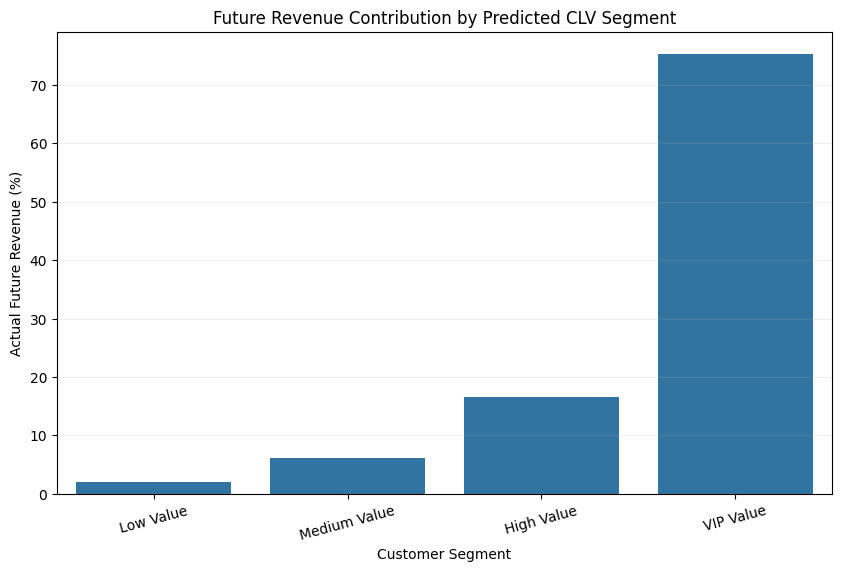

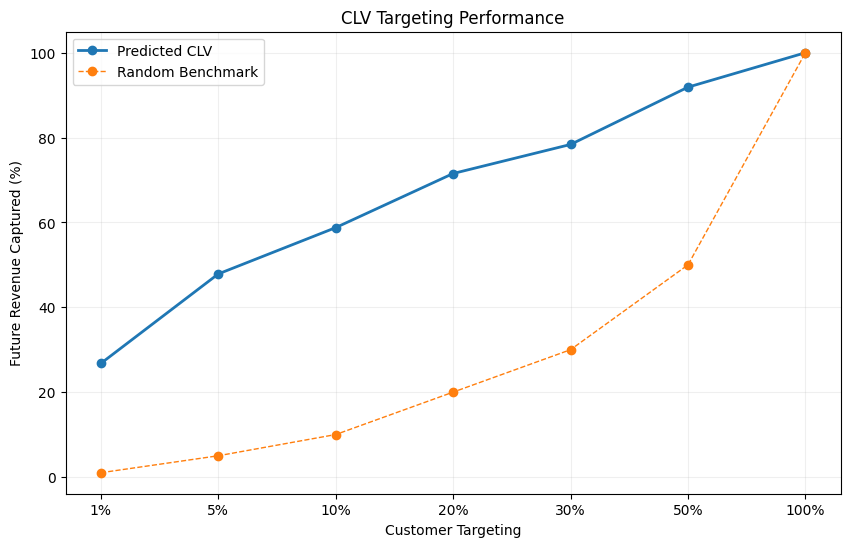


FINAL BUSINESS RECOMMENDATION
Prioritize the top 10% of customers based on predicted CLV.
This segment captured approximately 58.78% of actual future revenue in the test set.
The targeting strategy produced approximately 5.88x the revenue concentration of random customer selection.

VIP Value customers contributed approximately 75.32% of actual future revenue.
High + VIP customers together contributed 91.89% of actual future revenue.

Recommended action:
Use predicted CLV to prioritize retention, personalization, cross-selling, and premium customer service toward higher-value segments.


In [11]:
# ============================================================
# PROJECT 18 — CUSTOMER LIFETIME VALUE PREDICTION
# STEP 8 — FINAL CLV EXECUTIVE DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Model performance summary
# ------------------------------------------------------------

stage1_final = (
    stage1_comparison
    .copy()
)

stage2_final = (
    stage2_comparison
    .copy()
)

model_summary = pd.DataFrame({
    "Metric": [
        "Best Stage 1 Model",
        "Stage 1 ROC-AUC",
        "Best Stage 2 Model",
        "Stage 2 MAE",
        "Stage 2 RMSE",
        "Stage 2 R²",
        "Final CLV MAE",
        "Final CLV RMSE",
        "Final CLV R²",
        "Top 10% Revenue Capture",
        "Top 10% Lift vs Random",
        "Spearman Correlation"
    ],
    "Value": [
        best_stage1_name,

        stage1_final.iloc[0][
            "ROC_AUC"
        ],

        best_stage2_name,

        stage2_final.iloc[0][
            "MAE"
        ],

        stage2_final.iloc[0][
            "RMSE"
        ],

        stage2_final.iloc[0][
            "R2"
        ],

        final_mae,

        final_rmse,

        final_r2,

        top10_capture,

        top10_lift,

        spearman_correlation
    ]
})

# ------------------------------------------------------------
# 2. Display model summary
# ------------------------------------------------------------

print("=" * 90)
print("FINAL CLV MODEL SUMMARY")
print("=" * 90)

display(
    model_summary
)

# ------------------------------------------------------------
# 3. Customer segmentation summary
# ------------------------------------------------------------

final_segment_summary = (
    segment_summary
    [
        [
            "Customers",
            "Customer_Pct",
            "Avg_Predicted_CLV",
            "Avg_Actual_Revenue",
            "Actual_Revenue_Pct"
        ]
    ]
    .copy()
)

print(
    "\n" + "=" * 90
)

print(
    "FINAL CUSTOMER VALUE SEGMENTATION"
)

print(
    "=" * 90
)

display(
    final_segment_summary
)

# ------------------------------------------------------------
# 4. Business priority customers
# ------------------------------------------------------------

priority_customers = (
    segment_df[
        segment_df[
            "CLV_Segment"
        ].isin(
            [
                "High Value",
                "VIP Value"
            ]
        )
    ]
    .sort_values(
        "Predicted_CLV",
        ascending=False
    )
)

print(
    "\n" + "=" * 90
)

print(
    "BUSINESS PRIORITY CUSTOMERS"
)

print(
    "=" * 90
)

print(
    f"Priority customer count : "
    f"{len(priority_customers):,}"
)

print(
    f"Population share        : "
    f"{len(priority_customers) / len(segment_df) * 100:.2f}%"
)

print(
    f"Actual revenue share    : "
    f"{priority_customers['Actual_Future_Revenue'].sum() / total_actual_revenue * 100:.2f}%"
)

# ------------------------------------------------------------
# 5. Top 20 priority customers
# ------------------------------------------------------------

display(
    priority_customers[
        [
            "Actual_Future_Revenue",
            "Purchase_Probability",
            "Conditional_Revenue",
            "Predicted_CLV",
            "CLV_Segment",
            "Recommended_Action"
        ]
    ]
    .head(20)
)

# ------------------------------------------------------------
# 6. Executive KPI table
# ------------------------------------------------------------

executive_kpi = pd.DataFrame({
    "KPI": [
        "Historical Customers",
        "Customers with Future Purchase",
        "Future Purchase Rate",
        "Best Stage 1 Model",
        "Best Stage 2 Model",
        "Final CLV R²",
        "Top 10% Revenue Capture",
        "Top 10% Lift vs Random",
        "VIP Revenue Contribution",
        "High + VIP Revenue Contribution"
    ],
    "Value": [
        len(customer_clv),

        int(
            customer_clv[
                "Future_Revenue"
            ].gt(0).sum()
        ),

        (
            customer_clv[
                "Future_Revenue"
            ].gt(0).mean()
            * 100
        ),

        best_stage1_name,

        best_stage2_name,

        final_r2,

        top10_capture,

        top10_lift,

        segment_summary.loc[
            "VIP Value",
            "Actual_Revenue_Pct"
        ],

        (
            segment_summary.loc[
                [
                    "High Value",
                    "VIP Value"
                ],
                "Actual_Revenue_Pct"
            ]
            .sum()
        )
    ]
})

print(
    "\n" + "=" * 90
)

print(
    "EXECUTIVE KPI DASHBOARD"
)

print(
    "=" * 90
)

display(
    executive_kpi
)

# ------------------------------------------------------------
# 7. Plot CLV segment revenue contribution
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=(
        segment_summary
        .reset_index()
        .rename(
            columns={
                "CLV_Segment":
                    "Segment"
            }
        )
    ),
    x="Segment",
    y="Actual_Revenue_Pct",
    order=segment_order
)

plt.title(
    "Future Revenue Contribution by Predicted CLV Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Actual Future Revenue (%)"
)

plt.xticks(
    rotation=15
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 8. Plot CLV ranking effectiveness
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    ranking_report[
        "Targeting"
    ],
    ranking_report[
        "Revenue_Capture_Pct"
    ],
    marker="o",
    linewidth=2,
    label="Predicted CLV"
)

plt.plot(
    ranking_report[
        "Targeting"
    ],
    ranking_report[
        "Random_Benchmark_Pct"
    ],
    marker="o",
    linestyle="--",
    linewidth=1,
    label="Random Benchmark"
)

plt.title(
    "CLV Targeting Performance"
)

plt.xlabel(
    "Customer Targeting"
)

plt.ylabel(
    "Future Revenue Captured (%)"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()

# ------------------------------------------------------------
# 9. Final business recommendation
# ------------------------------------------------------------

print(
    "\n" + "=" * 90
)

print(
    "FINAL BUSINESS RECOMMENDATION"
)

print(
    "=" * 90
)

print(
    f"Prioritize the top 10% of customers based "
    f"on predicted CLV."
)

print(
    f"This segment captured approximately "
    f"{top10_capture:.2f}% of actual future revenue "
    f"in the test set."
)

print(
    f"The targeting strategy produced approximately "
    f"{top10_lift:.2f}x the revenue concentration "
    f"of random customer selection."
)

print(
    f"\nVIP Value customers contributed approximately "
    f"{segment_summary.loc['VIP Value', 'Actual_Revenue_Pct']:.2f}% "
    f"of actual future revenue."
)

print(
    f"High + VIP customers together contributed "
    f"{segment_summary.loc[['High Value', 'VIP Value'], 'Actual_Revenue_Pct'].sum():.2f}% "
    f"of actual future revenue."
)

print(
    "\nRecommended action:"
)

print(
    "Use predicted CLV to prioritize retention, "
    "personalization, cross-selling, and premium "
    "customer service toward higher-value segments."
)

## Key Findings

### 1. Future customer value is highly concentrated

The future revenue distribution is highly skewed, with 61.02% of historical customers generating no revenue during the future prediction period.

Among customers who generated future revenue, the mean future revenue was approximately 1,150.60, while the maximum reached approximately 168,490.60.

This indicates that customer value is highly concentrated among a relatively small group of customers.

### 2. Historical customer behavior contains predictive information

Historical customer behavior showed clear differences between customers who generated future revenue and those who did not.

Future buyers demonstrated substantially higher historical:

- Frequency
- Monetary value
- Total quantity
- Number of unique products
- Customer lifetime activity

This indicates that historical purchasing behavior contains useful information for estimating future customer value.

### 3. Monetary value was the strongest individual predictor

Among the historical behavioral variables, `Monetary` showed the strongest correlation with future revenue at approximately 0.59.

Other relatively important relationships included:

- `Total_Quantity`: approximately 0.48
- `Frequency`: approximately 0.37
- `Unique_Products`: approximately 0.25

These results suggest that customers with stronger historical purchasing activity tend to generate higher future revenue.

### 4. A two-stage modeling approach was appropriate

Because 61.02% of customers generated zero future revenue, the target variable was highly zero-inflated.

A two-stage modeling framework was therefore used:

```text
Stage 1
Future Purchase Prediction
        ↓
Purchase Probability

Stage 2
Conditional Future Revenue
        ↓
Expected Revenue

Purchase Probability
        ×
Conditional Revenue
        ↓
Predicted CLV


## Business Recommendations

```markdown
## Business Recommendations

### Prioritize High-Value Customers

The strongest business opportunity is concentrated among customers with high predicted CLV.

Customers in the VIP and High Value segments should receive greater attention through retention programs, personalized offers, and premium customer service.

### Use CLV for Targeted Customer Selection

The model indicates that targeting the top 10% of customers by predicted CLV can capture approximately 58.78% of actual future revenue in the test set.

This suggests that predicted CLV can be used to prioritize limited marketing or retention resources.

### Develop Segment-Specific Strategies

Different customer value segments should receive different levels of intervention.

```text
VIP Value
→ Priority retention
→ Personalized offers
→ Premium service

High Value
→ Retention campaigns
→ Cross-selling
→ Upselling

Medium Value
→ Personalized promotions
→ Product recommendations

Low Value
→ Low-cost automated engagement


## Conclusion

```markdown
## Conclusion

This project developed a Customer Lifetime Value prediction framework using historical transaction behavior to estimate future customer revenue and identify high-value customers.

The analysis used the Online Retail II dataset and applied a temporal modeling approach in which historical transactions were used to construct customer-level behavioral features, while a subsequent time period was used to measure future customer revenue.

Because 61.02% of customers generated zero future revenue, a two-stage modeling approach was implemented.

The first stage predicted the probability that a customer would generate future revenue using classification models, while the second stage estimated conditional future revenue for customers who generated a positive outcome.

Random Forest achieved the strongest Stage 1 performance with an ROC-AUC of approximately 0.8106.

Gradient Boosting achieved the strongest Stage 2 performance with an R² of approximately 0.6895.

The resulting two-stage CLV model achieved:

- MAE: **335.19**
- RMSE: **1,575.68**
- R²: **0.5889**

Although the regression metrics indicate that exact future revenue prediction remains challenging due to the highly skewed nature of customer spending, the model demonstrated useful customer-ranking capability.

The top 10% of customers ranked by predicted CLV captured approximately **58.78% of actual future revenue**, compared with a 10% random-targeting benchmark. This represents approximately **5.88× the revenue concentration of random targeting**.

The CLV segmentation further demonstrated substantial customer value concentration. The VIP segment represented 25% of evaluated customers while contributing approximately 75.32% of actual future revenue. High and VIP segments together accounted for approximately 91.89% of actual future revenue.

Overall, the project demonstrates how transaction data can be transformed into customer-level predictive value estimates and used to support targeted retention, personalization, cross-selling, and customer prioritization strategies.

The framework provides a foundation for developing broader customer intelligence systems that combine CLV, churn prediction, customer segmentation, and behavioral analytics.